In [2]:
from __future__ import annotations

import sys

sys.path.append("PATH TO src folder")
sys.path.append("PATH TO DIRECTORY CONTAINING THIS NOTEBOOK")

In [3]:
%load_ext autoreload
%autoreload 2

# Setting Up and Importing the Necessary Packages/Libraries
##Package for reading in Bruker OPUS type files
import pathlib

import matplotlib.pyplot as plt

from prospecpy.baseline import (
    arpls_baseline_second_deriv_weights,  # 7.1
    aspls_baseline,                       # asPLS
    raw_spline,  # arPLS 6.19
)

# Local Functions
from prospecpy.cut_range import cut_range_subtract_prospecpy_objects
from prospecpy.io import import_run_data
from prospecpy.second_deriv import second_deriv_prospecpy_objects


# Importing spectra data and water vapor data

# Creating Folders for Data and Plots

Within the data folder, create three more folders, water_vapor, output_plots, and one with a name describing this run or experiment.


In [4]:
# Paths to Local Data
path_to_water_vapor_data = pathlib.Path("../data/opus_files/water_vapor")
path_to_output_plots_ = pathlib.Path("../data/output_plots/")
# path_to_FILL_IN_data = pathlib.Path("../../data/opus_files/FILL_IN")
path_to_FILL_IN_data = pathlib.Path("../data/opus_files/pH6")

### Workflow Overview
The function called below `import_run_data`, creates a dict full of ProSpecPy objects, with empty attributes to be completed in the each of the following steps. For each of these steps, the function will write a corresponding plot labeled with the name of the sample to a folder describing the sample and step, within the `output_plots` directory specified above.


In [5]:
FILL_IN_raw_data = import_run_data(
    path_to_FILL_IN_data, input_type="raw spectra", output_folder="../output_plots/"
)

wv_data = import_run_data(path_to_water_vapor_data)

# Subtracting water vapor from raw spectra

Make sure to define the desired wave numbers for `range_start` and `range_end` which best fit your sample run.

In [6]:
# Initializing dict of post water vapor subtraction spectra
cut_range_subtract_prospecpy_objects(
    FILL_IN_raw_data, wv_data, range_start=2150, range_end=1850, showplots=False, verbose=True
)
# pH6_raw_data[].cut_subtracted_data

Plot saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/cut_range_subtracted_spectra
Atmospheric fit parameters saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/cut_atmfitparameters.csv
Cut subtracted data saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/cut_subtracted_data.csv
Plot saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/cut_range_subtracted_spectra
Atmospheric fit parameters saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/cut_atmfitparameters.csv
Cut subtracted data saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/cut_subtracted_data.csv
Plot saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/cut_range_subtracted_spectra
Atmospheric fit parameters saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/cut_atmfitparameters.csv
Cut subtracted data saved to ../output_plots//pH6/011c as iso Hyd2

## Get the second derivatives

In [7]:
second_deriv_prospecpy_objects(FILL_IN_raw_data, show_plots=False, verbose=True)

Plot saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/subtracted_spectra
Plot saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/second_derivative_fig
Second derivative csv data saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/second_derivative_data.csv
Plot saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/subtracted_spectra
Plot saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/second_derivative_fig
Second derivative csv data saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/second_derivative_data.csv
Plot saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/subtracted_spectra
Plot saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/second_derivative_fig
Second derivative csv data saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/second_derivative_data.csv
Plot saved to ../outpu

## asPLS


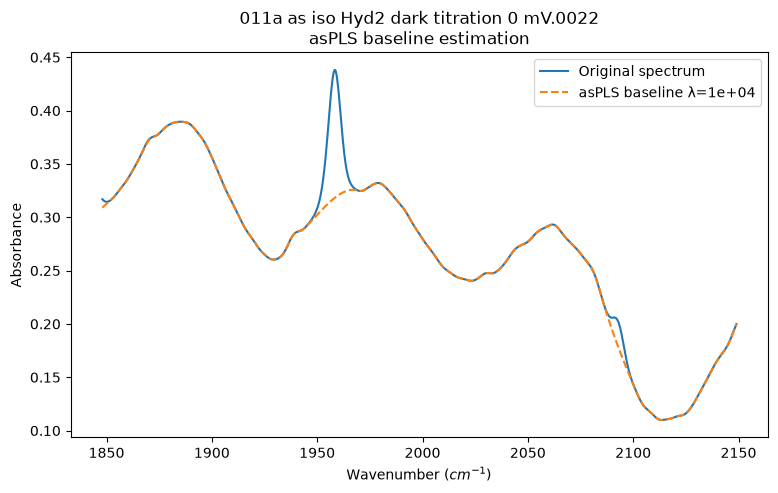

λ=1e+04 | iterations=101 | final tolerance=2.495e-02 | corrected min=-0.0000 | corrected max=0.1199


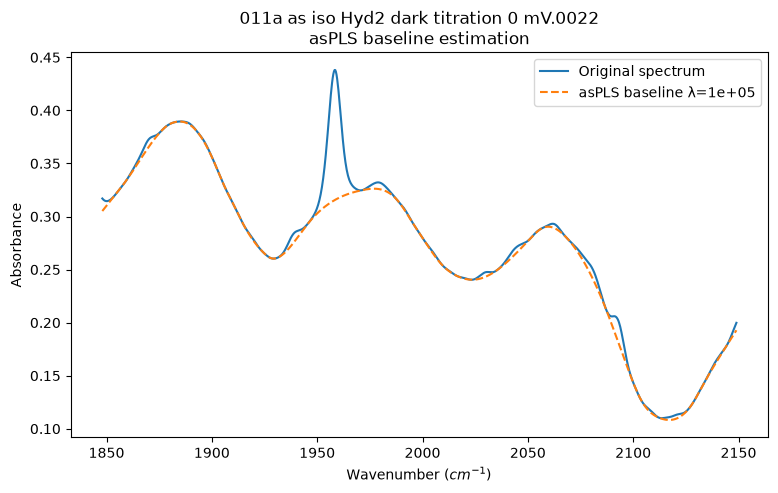

λ=1e+05 | iterations=101 | final tolerance=4.555e-03 | corrected min=-0.0001 | corrected max=0.1226


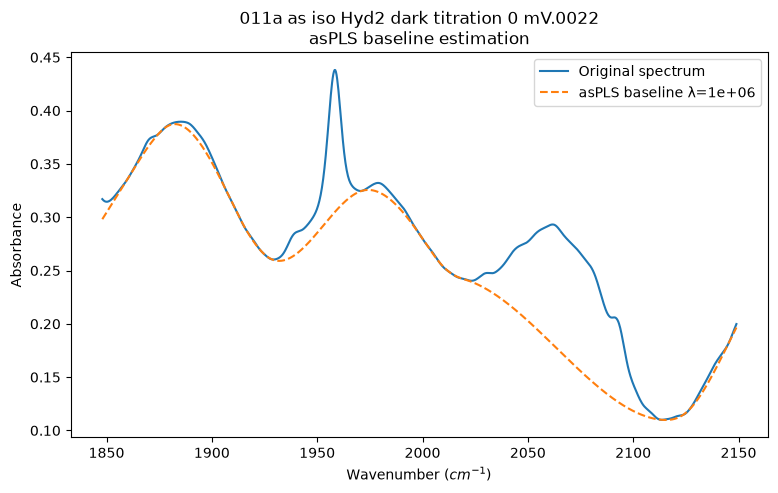

λ=1e+06 | iterations=101 | final tolerance=9.110e-02 | corrected min=-0.0004 | corrected max=0.1334


In [11]:
test_object = FILL_IN_raw_data[0]

raw_x, raw_y = raw_spline(
    test_object.get_subtracted_spectra_wavenumber(),
    test_object.get_subtracted_spectra_absorbance(),
)

lam_values = [1e4, 1e5, 1e6]

for lam in lam_values:
    baseline, params = aspls_baseline(
        raw_y,
        lam=lam,
        diff_order=2,
        max_iter=100,
        tol=1e-3,
        asymmetric_coef=0.5,
    )

    corrected = raw_y - baseline

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(
        raw_x,
        raw_y,
        label="Original spectrum",
    )

    ax.plot(
        raw_x,
        baseline,
        "--",
        label=f"asPLS baseline λ={lam:.0e}",
    )

    ax.set_xlabel(r"Wavenumber ($cm^{-1}$)")
    ax.set_ylabel("Absorbance")
    ax.set_title(
        f"{test_object.sample_name}\n"
        f"asPLS baseline estimation"
    )
    ax.legend()

    plt.show()

    print(
        f"λ={lam:.0e} | "
        f"iterations={len(params['tol_history'])} | "
        f"final tolerance={params['tol_history'][-1]:.3e} | "
        f"corrected min={corrected.min():.4f} | "
        f"corrected max={corrected.max():.4f}"
    )

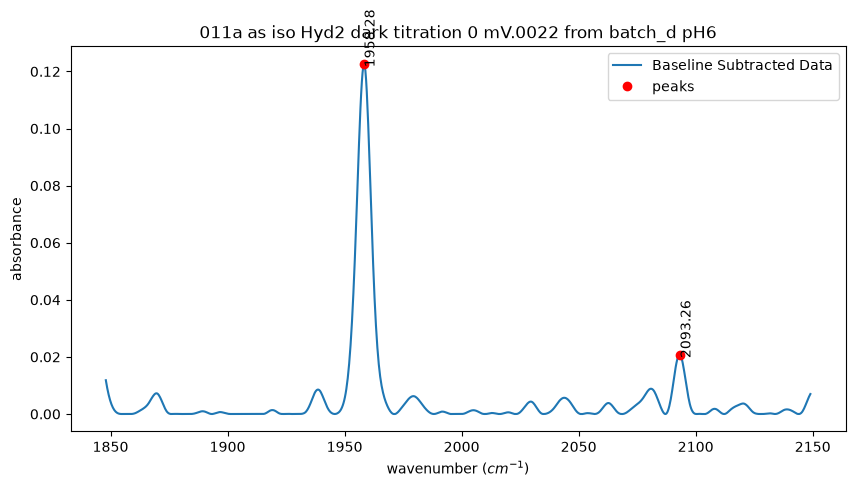

Plot saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/aspls_baseline_corrected_peak_info.csv


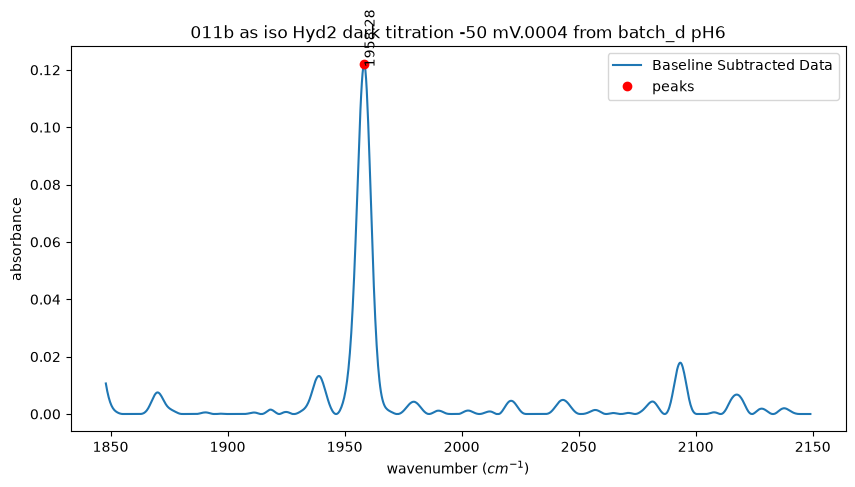

Plot saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/aspls_baseline_corrected_peak_info.csv


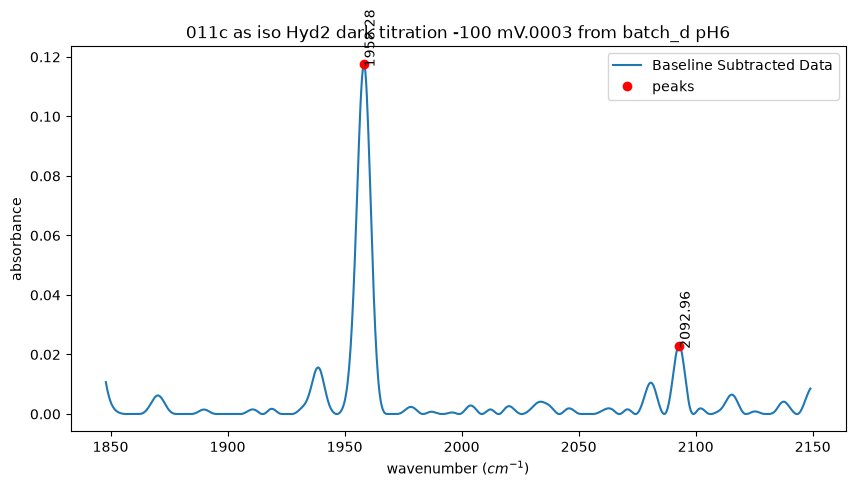

Plot saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/aspls_baseline_corrected_peak_info.csv


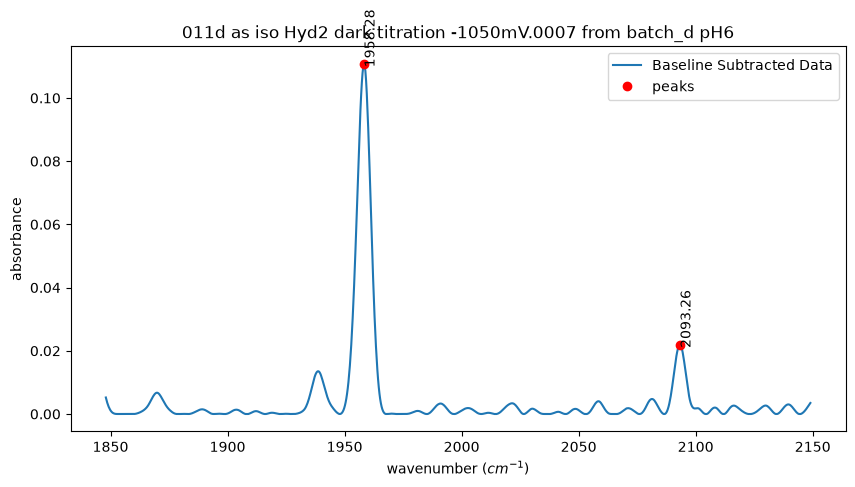

Plot saved to ../output_plots//pH6/011d as iso Hyd2 dark titration -1050mV.0007/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011d as iso Hyd2 dark titration -1050mV.0007/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011d as iso Hyd2 dark titration -1050mV.0007/aspls_baseline_corrected_peak_info.csv


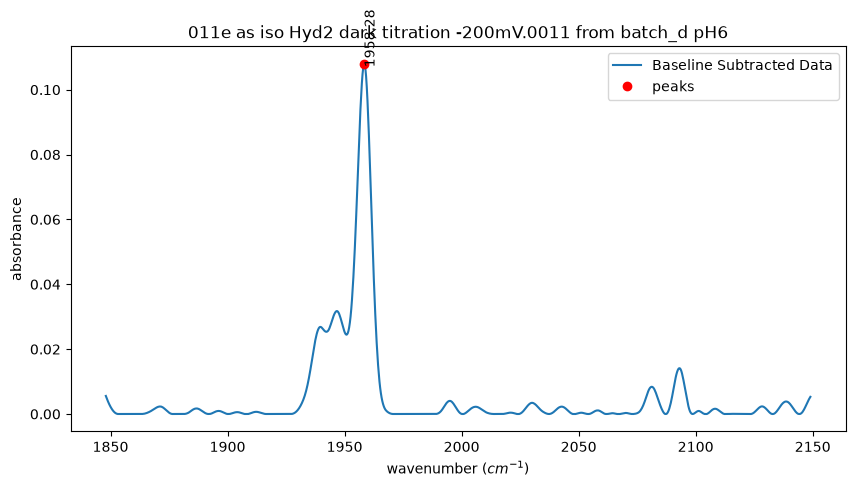

Plot saved to ../output_plots//pH6/011e as iso Hyd2 dark titration -200mV.0011/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011e as iso Hyd2 dark titration -200mV.0011/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011e as iso Hyd2 dark titration -200mV.0011/aspls_baseline_corrected_peak_info.csv


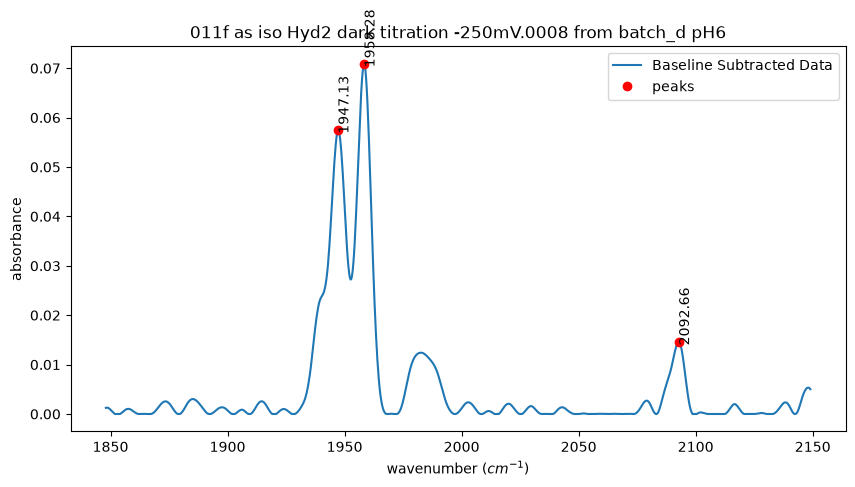

Plot saved to ../output_plots//pH6/011f as iso Hyd2 dark titration -250mV.0008/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011f as iso Hyd2 dark titration -250mV.0008/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011f as iso Hyd2 dark titration -250mV.0008/aspls_baseline_corrected_peak_info.csv


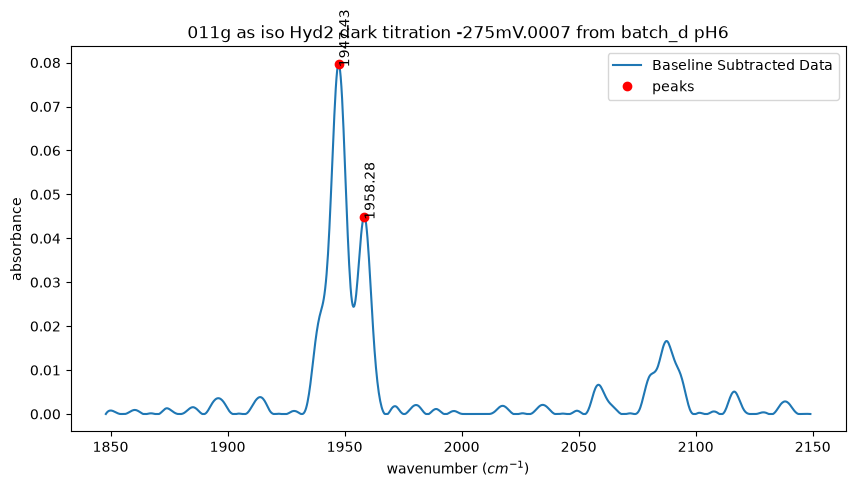

Plot saved to ../output_plots//pH6/011g as iso Hyd2 dark titration -275mV.0007/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011g as iso Hyd2 dark titration -275mV.0007/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011g as iso Hyd2 dark titration -275mV.0007/aspls_baseline_corrected_peak_info.csv


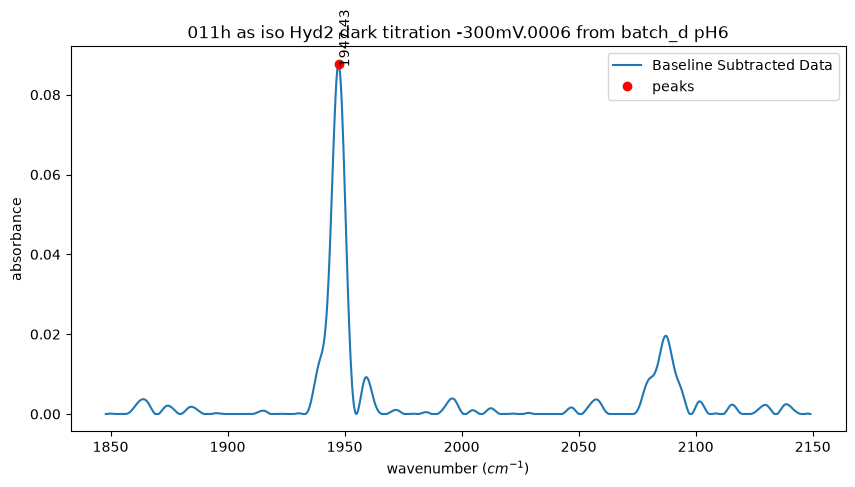

Plot saved to ../output_plots//pH6/011h as iso Hyd2 dark titration -300mV.0006/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011h as iso Hyd2 dark titration -300mV.0006/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011h as iso Hyd2 dark titration -300mV.0006/aspls_baseline_corrected_peak_info.csv


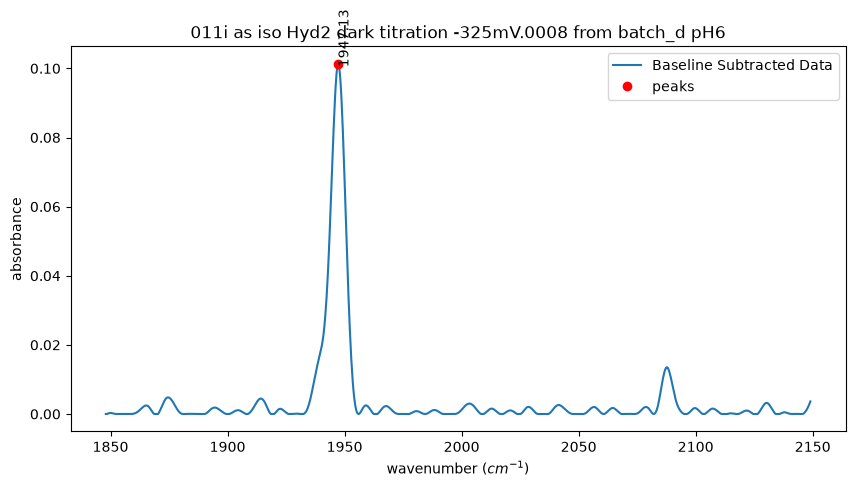

Plot saved to ../output_plots//pH6/011i as iso Hyd2 dark titration -325mV.0008/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011i as iso Hyd2 dark titration -325mV.0008/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011i as iso Hyd2 dark titration -325mV.0008/aspls_baseline_corrected_peak_info.csv


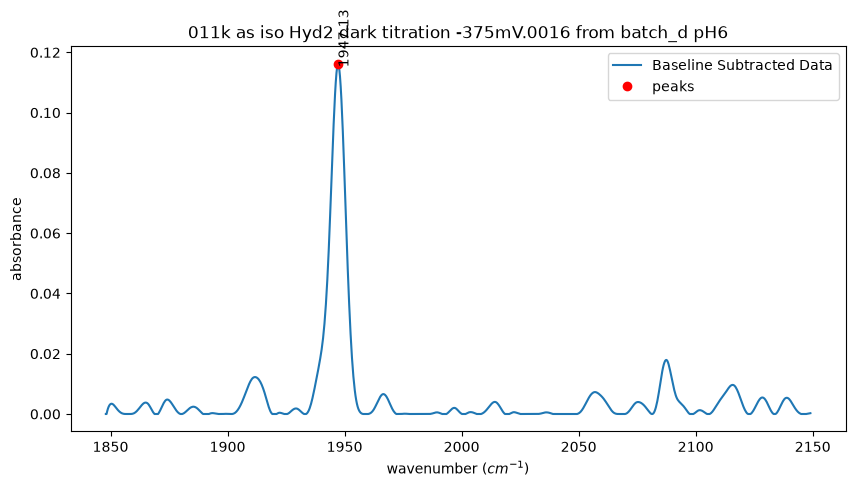

Plot saved to ../output_plots//pH6/011k as iso Hyd2 dark titration -375mV.0016/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011k as iso Hyd2 dark titration -375mV.0016/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011k as iso Hyd2 dark titration -375mV.0016/aspls_baseline_corrected_peak_info.csv


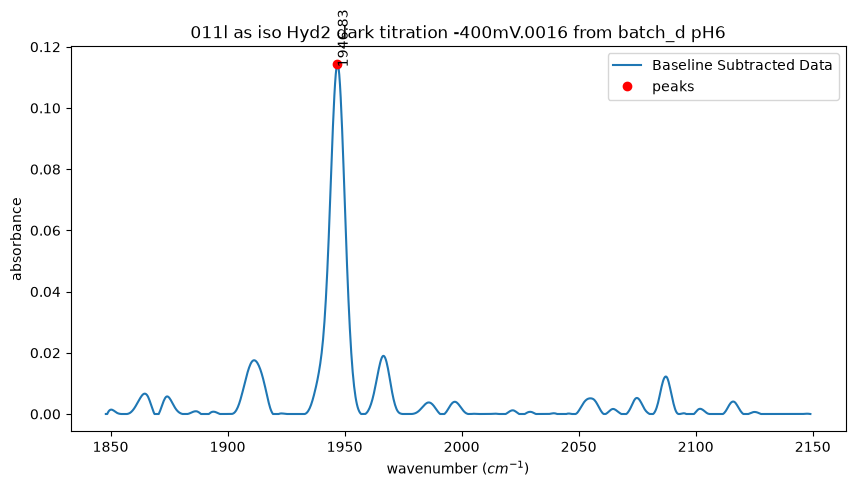

Plot saved to ../output_plots//pH6/011l as iso Hyd2 dark titration -400mV.0016/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011l as iso Hyd2 dark titration -400mV.0016/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011l as iso Hyd2 dark titration -400mV.0016/aspls_baseline_corrected_peak_info.csv


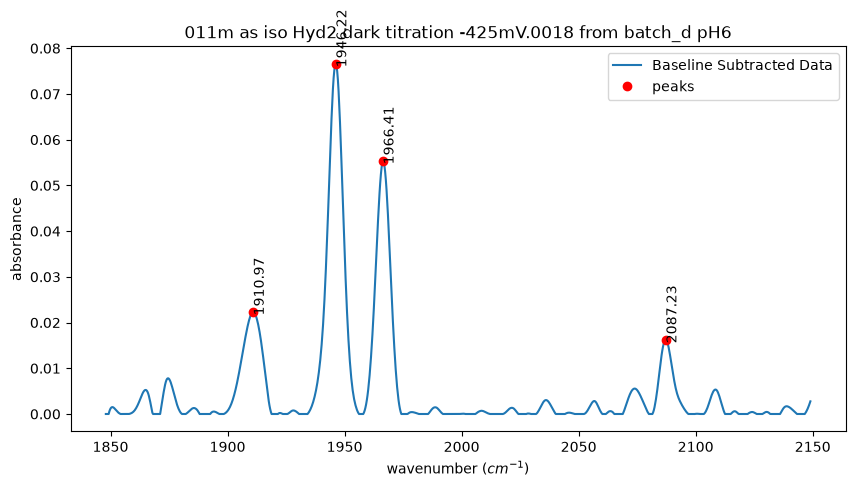

Plot saved to ../output_plots//pH6/011m as iso Hyd2 dark titration -425mV.0018/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011m as iso Hyd2 dark titration -425mV.0018/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011m as iso Hyd2 dark titration -425mV.0018/aspls_baseline_corrected_peak_info.csv


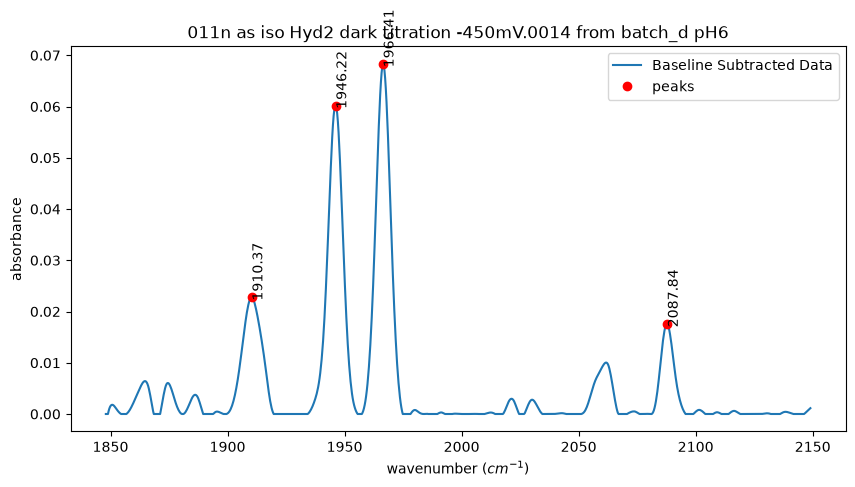

Plot saved to ../output_plots//pH6/011n as iso Hyd2 dark titration -450mV.0014/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011n as iso Hyd2 dark titration -450mV.0014/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011n as iso Hyd2 dark titration -450mV.0014/aspls_baseline_corrected_peak_info.csv


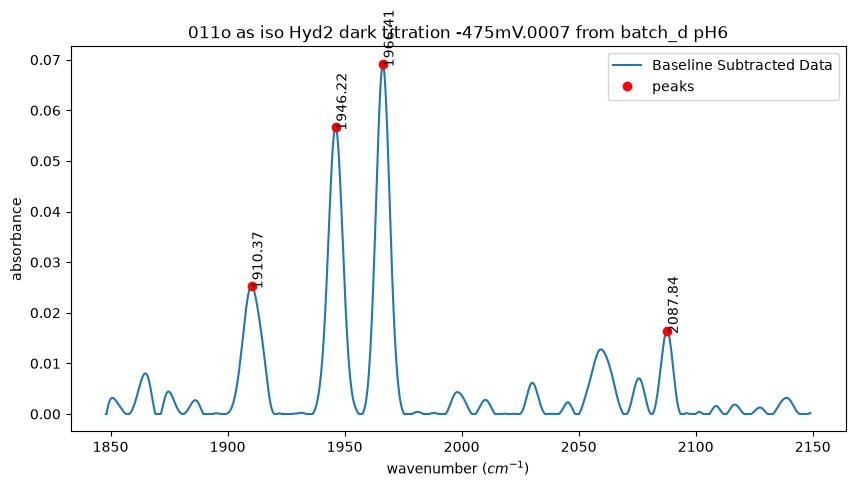

Plot saved to ../output_plots//pH6/011o as iso Hyd2 dark titration -475mV.0007/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011o as iso Hyd2 dark titration -475mV.0007/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011o as iso Hyd2 dark titration -475mV.0007/aspls_baseline_corrected_peak_info.csv


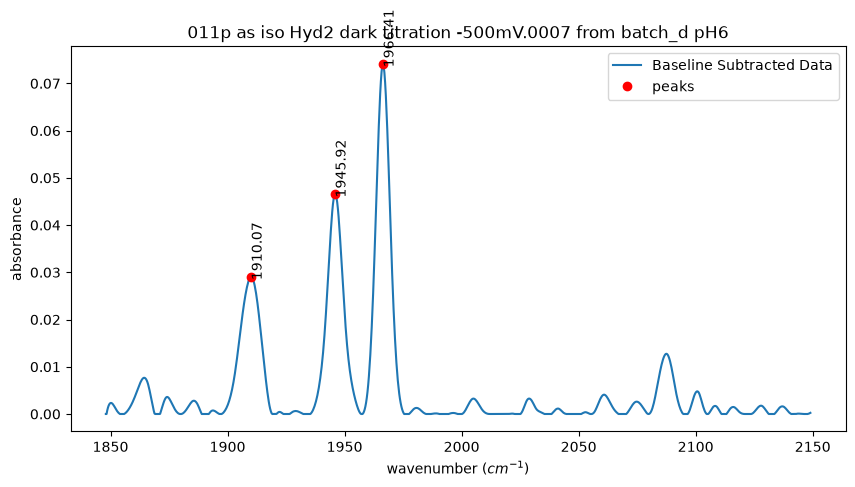

Plot saved to ../output_plots//pH6/011p as iso Hyd2 dark titration -500mV.0007/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011p as iso Hyd2 dark titration -500mV.0007/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011p as iso Hyd2 dark titration -500mV.0007/aspls_baseline_corrected_peak_info.csv


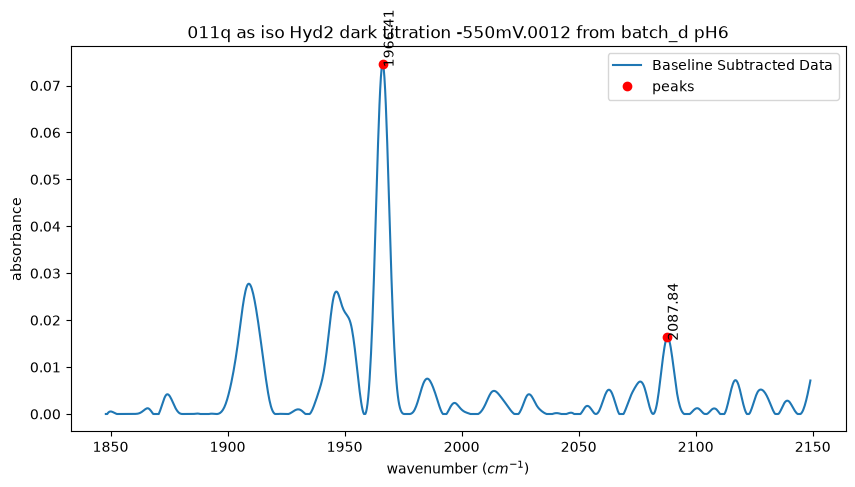

Plot saved to ../output_plots//pH6/011q as iso Hyd2 dark titration -550mV.0012/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011q as iso Hyd2 dark titration -550mV.0012/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011q as iso Hyd2 dark titration -550mV.0012/aspls_baseline_corrected_peak_info.csv


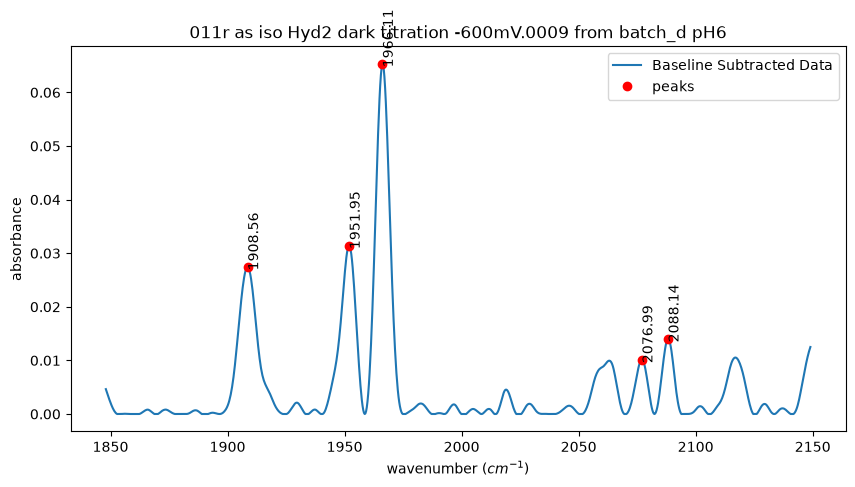

Plot saved to ../output_plots//pH6/011r as iso Hyd2 dark titration -600mV.0009/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011r as iso Hyd2 dark titration -600mV.0009/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011r as iso Hyd2 dark titration -600mV.0009/aspls_baseline_corrected_peak_info.csv


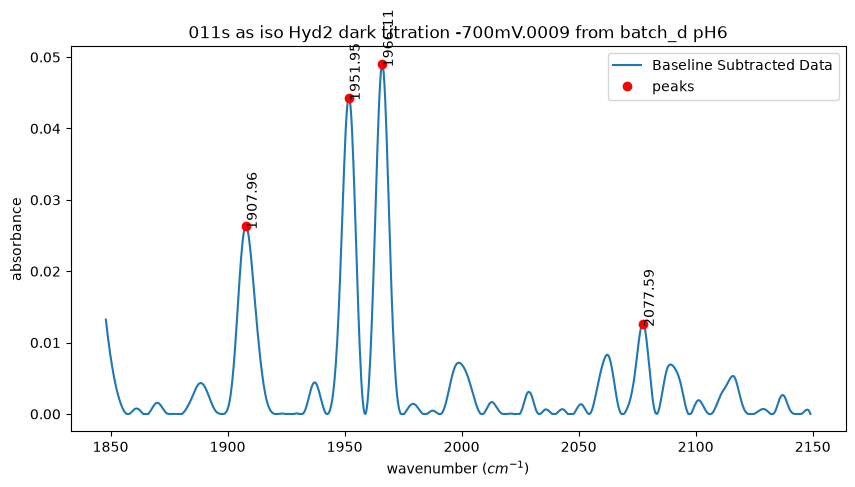

Plot saved to ../output_plots//pH6/011s as iso Hyd2 dark titration -700mV.0009/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011s as iso Hyd2 dark titration -700mV.0009/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011s as iso Hyd2 dark titration -700mV.0009/aspls_baseline_corrected_peak_info.csv


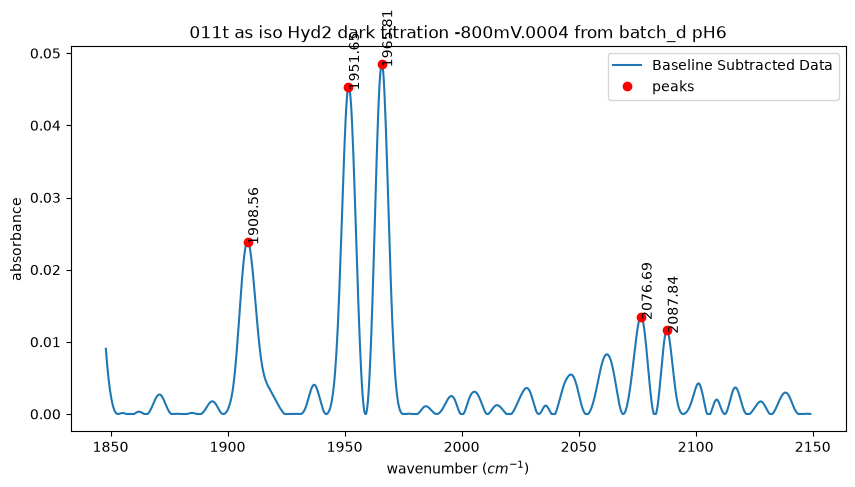

Plot saved to ../output_plots//pH6/011t as iso Hyd2 dark titration -800mV.0004/aspls_baseline_subtracted_spectra
asPLS corrected data saved to ../output_plots//pH6/011t as iso Hyd2 dark titration -800mV.0004/aspls_baseline_corrected_data.csv
asPLS peak information saved to ../output_plots//pH6/011t as iso Hyd2 dark titration -800mV.0004/aspls_baseline_corrected_peak_info.csv


In [9]:
selected_lam = 1e5
peak_threshold = 0.35

for obj in FILL_IN_raw_data:
    # Peak detection is still needed for the later peak information output
    obj.peak_finder(peak_threshold)

    # Apply asPLS baseline correction
    obj.subtract_baseline_aspls(
        lam=selected_lam,
        diff_order=2,
        max_iter=100,
        tol=1e-3,
        asymmetric_coef=0.5,
        save=True,
        showplot=True,
        verbose=True,
    )